In [3]:
# ============================================================
# K-Means Comparison: Brute Force, Approximation, Heuristic
# Full version: synthetic & real datasets, visualization & comparison
# ============================================================

In [4]:
import numpy as np
import itertools
import time
from sklearn.datasets import make_blobs, load_iris, load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

In [5]:
# ---------------- Utility Functions ------------------------
def sse(X, labels, centers):
    total = 0.0
    for i, x in enumerate(X):
        total += np.linalg.norm(x - centers[labels[i]])**2
    return total

def plot_clusters(X, labels, centers, title, filename, show=True):
    if X.shape[1] != 2:
        return
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis')
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='*', s=200, label='Centroids')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    if show:
        plt.show()
    plt.close()

In [6]:
# ---------------- Brute Force -----------------------------
def brute_force_kmeans(X, k):
    n = len(X)
    best_cost = float('inf')
    best_labels, best_centers = None, None
    for assignment in itertools.product(range(k), repeat=n):
        centers = []
        cost = 0.0
        for cluster in range(k):
            members = X[np.array(assignment) == cluster]
            if len(members) == 0:
                centers.append(np.zeros(X.shape[1]))
                continue
            centroid = np.mean(members, axis=0)
            centers.append(centroid)
            cost += np.sum(np.linalg.norm(members - centroid, axis=1)**2)
        if cost < best_cost:
            best_cost = cost
            best_labels = np.array(assignment)
            best_centers = np.array(centers)
    return best_labels, best_centers, best_cost

In [7]:
# ---------------- Approximation ---------------------------
def approx_kmeans(X, k):
    start = time.time()
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(X)
    end = time.time()
    return km.labels_, km.cluster_centers_, km.inertia_, end - start

In [8]:
# ---------------- Heuristic -------------------------------
def heuristic_kmeans(X, k, n_restarts=10):
    best_cost = float('inf')
    best_labels, best_centers = None, None
    total_time = 0.0
    for seed in range(n_restarts):
        start = time.time()
        km = KMeans(n_clusters=k, init='random', n_init=1, max_iter=300, random_state=seed)
        km.fit(X)
        end = time.time()
        cost = km.inertia_
        if cost < best_cost:
            best_cost = cost
            best_labels, best_centers = km.labels_, km.cluster_centers_
        total_time += (end - start)
    avg_time = total_time / n_restarts
    return best_labels, best_centers, best_cost, avg_time

In [9]:
# ---------------- Experiment Runner -----------------------

def run_experiments(datasets, show_plots=True):
    results = []
    for name, X, y_true in datasets:
        n, d = X.shape
        k = len(np.unique(y_true)) if y_true is not None else 3
        print(f"\n=== Dataset: {name} | n={n}, d={d}, k={k} ===")

        # Use PCA for visualization if dimensions > 2
        if d > 2:
            pca = PCA(n_components=2)
            X_vis = pca.fit_transform(X)
        else:
            pca = None
            X_vis = X

        # Brute Force only for small datasets
        if n <= 10:
            start = time.time()
            labels_bf, centers_bf, cost_bf = brute_force_kmeans(X, k)
            time_bf = time.time() - start
            centers_bf_vis = pca.transform(centers_bf) if pca else centers_bf
            plot_clusters(X_vis, labels_bf, centers_bf_vis, f"Brute Force ({name})", f"bf_{name}.png", show=show_plots)
        else:
            labels_bf = centers_bf = cost_bf = time_bf = None

        # Approximation (k-means++)
        labels_app, centers_app, cost_app, time_app = approx_kmeans(X, k)
        centers_app_vis = pca.transform(centers_app) if pca else centers_app
        plot_clusters(X_vis, labels_app, centers_app_vis, f"k-means++ ({name})", f"app_{name}.png", show=show_plots)

        # Heuristic (Lloyd with random restarts)
        labels_heu, centers_heu, cost_heu, time_heu = heuristic_kmeans(X, k, n_restarts=10)
        centers_heu_vis = pca.transform(centers_heu) if pca else centers_heu
        plot_clusters(X_vis, labels_heu, centers_heu_vis, f"Lloyd Heuristic ({name})", f"heu_{name}.png", show=show_plots)

        # ARI for evaluation
        ari_app = adjusted_rand_score(y_true, labels_app) if y_true is not None else None
        ari_heu = adjusted_rand_score(y_true, labels_heu) if y_true is not None else None

        results.append({
            'dataset': name,
            'n': n,
            'd': d,
            'bf_cost': cost_bf,
            'app_cost': cost_app,
            'heu_cost': cost_heu,
            'bf_time': time_bf,
            'app_time': time_app,
            'heu_time': time_heu,
            'ari_app': ari_app,
            'ari_heu': ari_heu
        })
    return results

In [10]:
# ---------------- Plot SSE and Runtime ---------------------
def plot_results(results, show=True):
    ns = [r['n'] for r in results]
    datasets = [r['dataset'] for r in results]

    # ---- SSE Plot ----
    plt.figure(figsize=(6, 4))
    plt.plot(ns, [r['app_cost'] for r in results], 'o-', label='k-means++')
    plt.plot(ns, [r['heu_cost'] for r in results], 's--', label='Heuristic')
    bf_points = [(r['n'], r['bf_cost']) for r in results if r['bf_cost'] is not None]
    if bf_points:
        bf_ns, bf_costs = zip(*bf_points)
        plt.plot(bf_ns, bf_costs, 'x-.', label='Brute Force')
    plt.xlabel('Number of Points (n)')
    plt.ylabel('SSE (Cost)')
    plt.title('SSE vs Dataset')
    plt.legend()
    plt.tight_layout()
    plt.savefig('cost_vs_dataset.png', dpi=300)
    if show:
        plt.show()
    plt.close()

    # ---- Runtime Plot ----
    plt.figure(figsize=(6, 4))
    plt.plot(ns, [r['app_time'] for r in results], 'o-', label='k-means++')
    plt.plot(ns, [r['heu_time'] for r in results], 's--', label='Heuristic')
    bf_points_time = [(r['n'], r['bf_time']) for r in results if r['bf_time'] is not None]
    if bf_points_time:
        bf_ns, bf_times = zip(*bf_points_time)
        plt.plot(bf_ns, bf_times, 'x-.', label='Brute Force')
    plt.xlabel('Number of Points (n)')
    plt.ylabel('Runtime (seconds)')
    plt.title('Runtime vs Dataset')
    plt.legend()
    plt.tight_layout()
    plt.savefig('time_vs_dataset.png', dpi=300)
    if show:
        plt.show()
    plt.close()


=== Dataset: Iris | n=150, d=4, k=3 ===


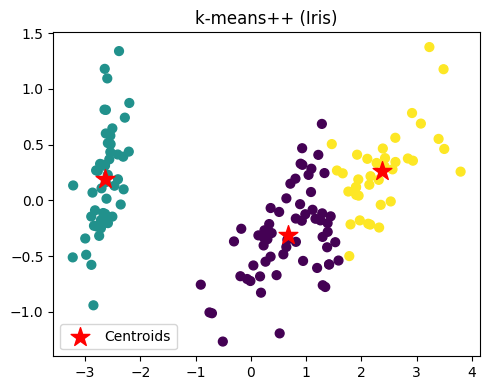

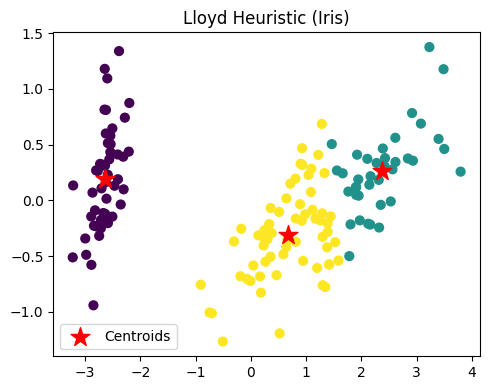


=== Dataset: Wine | n=178, d=13, k=3 ===


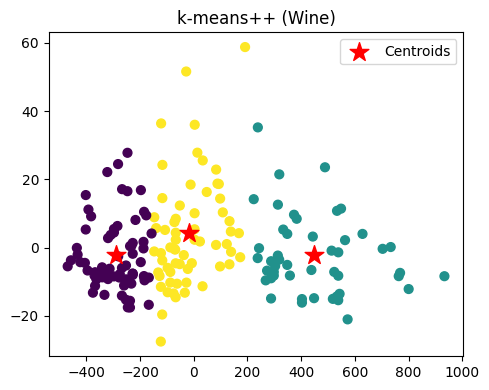

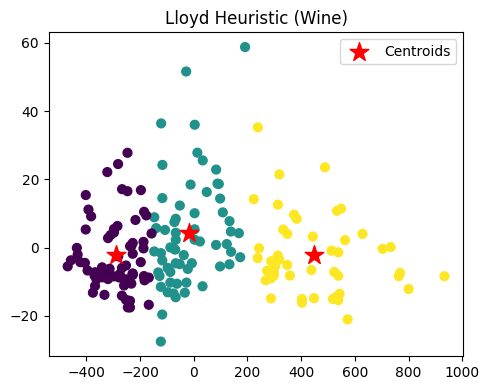


=== Summary Table ===
{'dataset': 'Iris', 'n': 150, 'd': 4, 'bf_cost': None, 'app_cost': 78.85144142614601, 'heu_cost': 78.85144142614601, 'bf_time': None, 'app_time': 0.023967266082763672, 'heu_time': 0.002095818519592285, 'ari_app': 0.7302382722834697, 'ari_heu': 0.7302382722834697}
{'dataset': 'Wine', 'n': 178, 'd': 13, 'bf_cost': None, 'app_cost': 2370689.686782968, 'heu_cost': 2370689.686782968, 'bf_time': None, 'app_time': 0.014984607696533203, 'heu_time': 0.0018000125885009766, 'ari_app': 0.37111371823084754, 'ari_heu': 0.37111371823084754}


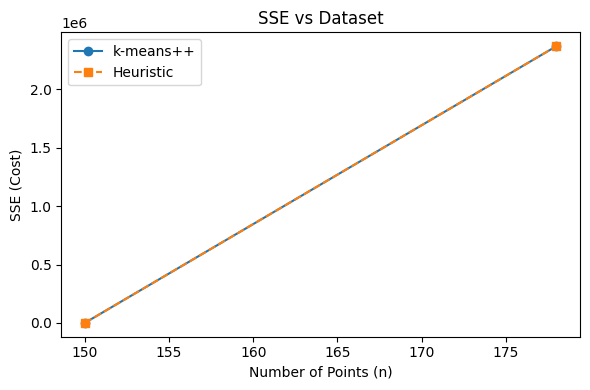

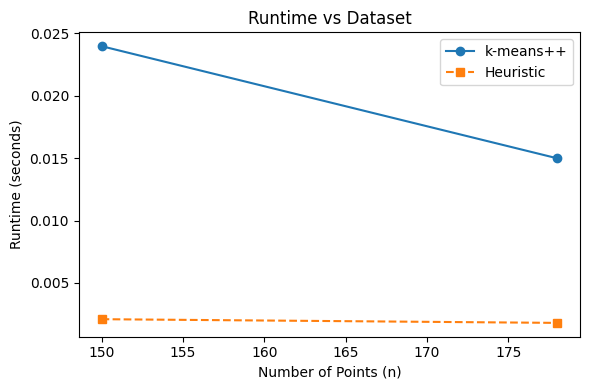

In [11]:
# ---------------- Main -------------------------------------
if __name__ == "__main__":
    # Prepare datasets: (name, X, y_true)
    datasets = []

    # Real datasets
    data_iris = load_iris()
    datasets.append(("Iris", data_iris.data, data_iris.target))
    data_wine = load_wine()
    datasets.append(("Wine", data_wine.data, data_wine.target))

    # Run experiments
    results = run_experiments(datasets, show_plots=True)

    # Print summary table
    print("\n=== Summary Table ===")
    for r in results:
        print(r)

    # Plot SSE and runtime comparison
    plot_results(results, show=True)